# Siren Exploration

This is a colab to explore properties of the Siren MLP, proposed in the work [Implicit Neural Activations with Periodic Activation Functions](https://vsitzmann.github.io/siren). Here, I am applying it to an MRI 4D flow dataset in a human aorta.


We will first implement a streamlined version of Siren for fast experimentation. This lacks the code to easily do baseline comparisons - please refer to the main code for that - but will greatly simplify the code!

Let's go! First, some imports, and a function to quickly generate coordinate grids.

In [163]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import os

from PIL import Image
from torchvision.transforms import Resize, Compose, ToTensor, Normalize
import numpy as np
import skimage
import matplotlib.pyplot as plt

import time

# JBM dependencies for our data: 
import h5py

def get_mgrid(sidelen, dim=2):
    '''Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int'''
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

# JBM: the following is an adaptation of the mgrid function to create coordinate grids for 
# unevenly dimensioned datasets. We need this for aorta data (usually a long rectangle!)
def get_mgrid_arbstep(sidelen_x, sidelen_y, sidelen_z, dim=3):
    '''Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    Allows for different number of samples along different axes. 
    sidelen: int
    dim: int'''
    tensorx = torch.linspace(-1, 1, steps=sidelen_x)
    tensory = torch.linspace(-1, 1, steps=sidelen_y)
    tensorz = torch.linspace(-1, 1, steps=sidelen_z)

    mgrid = torch.stack(torch.meshgrid([tensorx, tensory, tensorz]), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

In [164]:
# This cell is just to test my arbstep mgrid
mgrid = get_mgrid(100,dim=3)
mgrid = get_mgrid_arbstep(100,100,100,dim=3)

Now, we code up the sine layer, which will be the basic building block of SIREN. This is a much more concise implementation than the one in the main code, as here, we aren't concerned with the baseline comparisons.

In [165]:
class SineLayer(nn.Module):
    # See paper sec. 3.2, final paragraph, and supplement Sec. 1.5 for discussion of omega_0.
    
    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the 
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a 
    # hyperparameter.
    
    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of 
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)
    
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        
        self.init_weights()
    
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 
                                             1 / self.in_features)      
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, 
                                             np.sqrt(6 / self.in_features) / self.omega_0)
        
    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))
    
    def forward_with_intermediate(self, input): 
        # For visualization of activation distributions
        intermediate = self.omega_0 * self.linear(input)
        return torch.sin(intermediate), intermediate
    
    
class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features, outermost_linear=False, 
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, 
                                  is_first=True, omega_0=first_omega_0))

        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, 
                                      is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            
            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0, 
                                              np.sqrt(6 / hidden_features) / hidden_omega_0)
                
            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features, 
                                      is_first=False, omega_0=hidden_omega_0))
        
        self.net = nn.Sequential(*self.net)
    
    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True) # allows to take derivative w.r.t. input
        output = self.net(coords)
        return output, coords        

    def forward_with_activations(self, coords, retain_grad=False):
        '''Returns not only model output, but also intermediate activations.
        Only used for visualizing activations later!'''
        activations = OrderedDict()

        activation_count = 0
        x = coords.clone().detach().requires_grad_(True)
        activations['input'] = x
        for i, layer in enumerate(self.net):
            if isinstance(layer, SineLayer):
                x, intermed = layer.forward_with_intermediate(x)
                
                if retain_grad:
                    x.retain_grad()
                    intermed.retain_grad()
                    
                activations['_'.join((str(layer.__class__), "%d" % activation_count))] = intermed
                activation_count += 1
            else: 
                x = layer(x)
                
                if retain_grad:
                    x.retain_grad()
                    
            activations['_'.join((str(layer.__class__), "%d" % activation_count))] = x
            activation_count += 1

        return activations

JBM: We're going to do another trick here: use a fourier feature transform. These are shown to quite drastically improve the performance of INR fitting, especially where high-frequency features are concerned. This was not used in the initial SIREN notebook

In [166]:
class GaussianFourierFeatureTransform(torch.nn.Module):
    """
    An implementation of Gaussian Fourier feature mapping.

    "Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains":
       https://arxiv.org/abs/2006.10739
       https://people.eecs.berkeley.edu/~bmild/fourfeat/index.html

    Given an input of size [batches, num_input_channels, width, height],
     returns a tensor of size [batches, mapping_size*2, width, height].
    """

    def __init__(self, num_input_channels, mapping_size=256, scale=10):
        super().__init__()

        self._num_input_channels = num_input_channels
        self._mapping_size = mapping_size
        self._B = torch.randn((num_input_channels, mapping_size)) * scale

    def forward(self, x):

        x = x @ self._B.to(x.device)

        x = 2 * np.pi * x
        return torch.cat([torch.sin(x), torch.cos(x)], dim=2)

<a id='section_1'></a>
## Fitting a 4D flow dataset

First, let's simply fit a static (no time dimension) dataset!

We seek to parameterize a velocity vector field $f(x)$ with voxel coordinates $x$ with a SIREN $\Phi(x)$.

That is we seek the function $\Phi$ such that:
$\mathcal{L}=\int_{\Omega} \lVert \Phi(\mathbf{x}) - f(\mathbf{x}) \rVert\mathrm{d}\mathbf{x}$
 is minimized, in which $\Omega$ is the domain of the 4D flow dataset. 
 
We write a little datast that does nothing except calculating per-pixel coordinates, and gets our pixel values (velocity) properly structured:

In [167]:
class FlowFitting(Dataset):
    def __init__(self, sidelength_x, sidelength_y, sidelength_z, u, v, w, t):
        super().__init__()
        # img = get_cameraman_tensor(sidelength)
        # self.pixels = img.permute(1, 2, 0).view(-1, 1)

        u = u[t,:,:,:].flatten()
        v = v[t,:,:,:].flatten()
        w = w[t,:,:,:].flatten()

        # self.pixels = torch.cat((u[:,None], v[:,None], w[:,None]), dim=1)
        self.pixels = torch.stack((u, v, w),dim=-1)
        
        self.coords = get_mgrid_arbstep(sidelength_x, sidelength_y, sidelength_z)

        nonzeros = self.pixels != 0
        self.mask = self.pixels.masked_fill(~nonzeros,0)
        self.mask = self.pixels.masked_fill(nonzeros,1)

        print("Coord shape = ", np.shape(self.coords))
        print("Flow v ('pixels') output shape = ", np.shape(self.pixels))
        print("Mask shape = ", np.shape(self.mask))

    def __len__(self):
        return 1

    def __getitem__(self, idx):    
        if idx > 0: raise IndexError
            
        return self.coords, self.pixels

Before actually getting it in dataset format, do some loading and processing of the .h5 4D flow data. I'd like to combine this with the class above in the future, but for now it is totally fine to run with the following: 

Keys: <KeysViewHDF5 ['SNRdb', 'mag_u', 'mag_v', 'mag_w', 'mask', 'u', 'v', 'venc_u', 'venc_v', 'venc_w', 'w']>
<class 'h5py._hl.dataset.Dataset'>


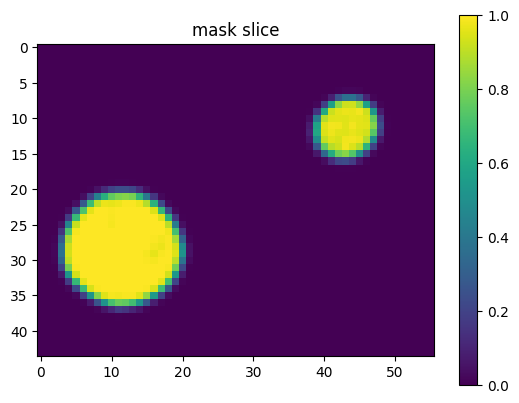

Shape of u =  torch.Size([71, 164, 44, 56])


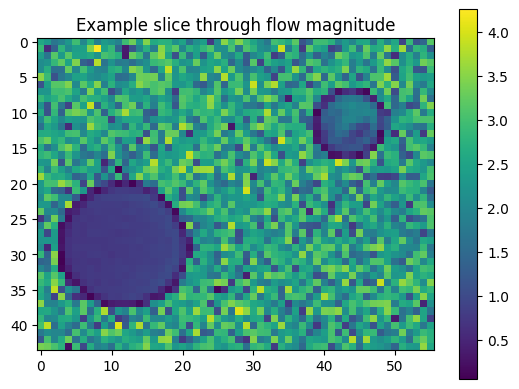

In [168]:
# JBM Load the (LR) data via h5py
filename = "data/aorta03trans_LR.h5"
with h5py.File(filename, "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]

    # get the object type for a_group_key: usually group or dataset
    print(type(f[a_group_key])) 

    # If a_group_key is a group name, 
    # this gets the object names in the group and returns as a list
    data = list(f[a_group_key])

    # If a_group_key is a dataset name, 
    # this gets the dataset values and returns as a list
    data = list(f[a_group_key])
    # preferred methods to get dataset values:
    ds_obj = f[a_group_key]      # returns as a h5py dataset object
    u_np = f['u'][()]  # returns as a numpy array
    v_np = f['v'][()]  # returns as a numpy array
    w_np = f['w'][()]  # returns as a numpy array
    mask_np = f['mask'][()]
    plt.imshow(np.squeeze(mask_np[:,41,:,:]))
    plt.title('mask slice')
    plt.colorbar()
    plt.show()
    mask_all_slice = torch.from_numpy(np.repeat(mask_np,71,axis=0))

     
    # convert all to tensor
    u = torch.from_numpy(u_np)
    v = torch.from_numpy(v_np)
    w = torch.from_numpy(w_np)

    # normalize to [-1,1] 
    max_vel = torch.max(torch.tensor([torch.max(u),torch.max(v),torch.max(w)]))
    u = u/max_vel
    v = v/max_vel
    w = w/max_vel

    mask_velocities = True
    if mask_velocities:
        u = u * mask_all_slice
        v = v * mask_all_slice
        w = w * mask_all_slice
    
    # Coords: [T, X, Y, Z]
    print('Shape of u = ', np.shape(u))
    plt.imshow(np.sqrt(u_np[15,41,:,:]**2 + v_np[15,41,:,:]**2 + w_np[15,41,:,:]**2))
    plt.title('Example slice through flow magnitude')
    plt.colorbar()
    plt.show()


Let's instantiate the dataset and our Siren. As pixel coordinates are 3D, the feature transformer has 3 input features, and since the 4D flow data is a 3D vector, the output size has 3 features. Since the flow is input -> transformer -> network, the network takes in the size of the fourier features

In [177]:
flowd = FlowFitting(164,44,56, u, v, w, t=15)
dataloader = DataLoader(flowd, batch_size=1, pin_memory=True, num_workers=0)

num_fourier_features = 256
feature_transformer = GaussianFourierFeatureTransform(num_input_channels=3,
                                                      mapping_size=num_fourier_features, scale=5)

# Initial experiment with just XYZ, no T coordinate. Outputs UVW
img_siren = Siren(in_features=2*num_fourier_features, out_features=3, hidden_features=256, 
                  hidden_layers=3, outermost_linear=True)

# TODO(JBM): need to provide option to use CUDA if GPU AVAILABLE. This currently just runs on CPU, wh
#img_siren.cuda()

Coord shape =  torch.Size([404096, 3])
Flow v ('pixels') output shape =  torch.Size([404096, 3])
Mask shape =  torch.Size([404096, 3])


We now fit Siren in a simple training loop. Within only hundreds of iterations, the 4D flow dataset (at one timepoint) is approximated well. Note - this is an unoptimized Siren! You can definitely get much better performance if you think a little harder about architecture, hyperparameters, etc. 

In [178]:
total_steps = 200 # Since the whole image is our dataset, this just means 500 gradient descent steps.
steps_til_summary = 10

optim = torch.optim.Adam(lr=1e-4, weight_decay=1e-3, params=img_siren.parameters())

model_input, ground_truth = next(iter(dataloader))
model_input = feature_transformer(model_input)

# TODO(JBM): need to provide option to use CUDA if GPU AVAILABLE
#model_input, ground_truth = model_input.cuda(), ground_truth.cuda()

for step in range(total_steps):
    model_output, coords = img_siren(model_input)    
    #loss = ((mask*(model_output - ground_truth)**2)).mean()
    # JBM: only considering loss inside the vessels. Thus will get junk outside of aorta, but don't really care! 
    loss = ((flowd.mask*(model_output - ground_truth)**2)).mean()

    if not step % steps_til_summary:
        print("Step %d, Total loss %0.6f" % (step, loss))

    optim.zero_grad()
    loss.backward()
    optim.step()

Step 0, Total loss 0.001754
Step 10, Total loss 0.001154
Step 20, Total loss 0.000682
Step 30, Total loss 0.000431
Step 40, Total loss 0.000163
Step 50, Total loss 0.000099
Step 60, Total loss 0.000056
Step 70, Total loss 0.000043
Step 80, Total loss 0.000049
Step 90, Total loss 0.000063
Step 100, Total loss 0.000042
Step 110, Total loss 0.000032
Step 120, Total loss 0.000024
Step 130, Total loss 0.000023
Step 140, Total loss 0.000341
Step 150, Total loss 0.000110
Step 160, Total loss 0.000050
Step 170, Total loss 0.000031
Step 180, Total loss 0.000022
Step 190, Total loss 0.000019


tensor([[-1.0000, -1.0000],
        [-1.0000, -0.9866],
        [-1.0000, -0.9732],
        ...,
        [ 1.0000,  0.9732],
        [ 1.0000,  0.9866],
        [ 1.0000,  1.0000]])
torch.Size([1, 22500, 3])


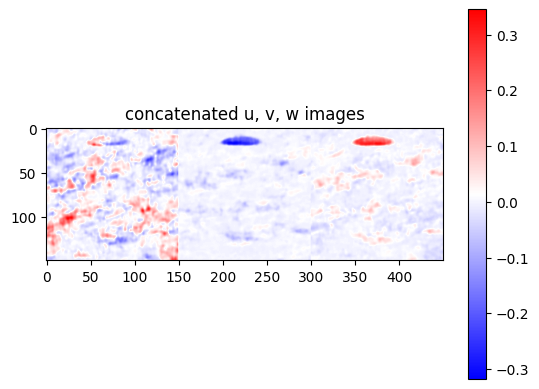

In [179]:
# print(np.shape(model_output))
# model_output_reshape = model_output[:,:,1].cpu().view(164,44,56).detach().numpy()
# plt.imshow(model_output_reshape[:,20,:])
# plt.colorbar()
# plt.show()

eval_dim = 150
mgrid = get_mgrid(eval_dim)
print(mgrid)
zgrid = torch.ones((eval_dim*eval_dim,1))*0
mgrid = torch.cat((mgrid,zgrid),1)
mgrid = mgrid[None,:,:]

model_output_slice, coords = img_siren(feature_transformer(mgrid))
print(np.shape(model_output_slice))
model_output_slice_u = model_output_slice[:,:,0]
model_output_slice_v = model_output_slice[:,:,1]
model_output_slice_w = model_output_slice[:,:,2]

u_img = model_output_slice_u.cpu().view(eval_dim,eval_dim).detach().numpy()
v_img = model_output_slice_v.cpu().view(eval_dim,eval_dim).detach().numpy()
w_img = model_output_slice_w.cpu().view(eval_dim,eval_dim).detach().numpy()

plt.imshow(np.concatenate((u_img,v_img,w_img),axis=1), cmap='bwr')
plt.title('concatenated u, v, w images')
plt.colorbar()
plt.show()

In [185]:
# OK, let's now make a gif through this dataset at this time 
tgrid = np.linspace(-1,1,100)
images = []

folder_path = 'out_images/'
if not os.path.exists(folder_path):
  os.makedirs(folder_path)
  print(f"Folder '{folder_path}' created.")
else:
  print(f"Folder '{folder_path}' already exists.")

for i in range(tgrid.shape[0]):
    # Access each slice (2D array)
    mgrid = get_mgrid(eval_dim)
    zgrid = torch.ones((eval_dim*eval_dim,1))*tgrid[i]
    mgrid = torch.cat((mgrid,zgrid),1)
    mgrid = mgrid[None,:,:]

    model_output_slice, coords = img_siren(feature_transformer(mgrid))
    model_output_slice_u = model_output_slice[:,:,0]
    model_output_slice_v = model_output_slice[:,:,1]
    model_output_slice_w = model_output_slice[:,:,2]
    
    u_img = model_output_slice_u.cpu().view(eval_dim,eval_dim).detach().numpy()
    v_img = model_output_slice_v.cpu().view(eval_dim,eval_dim).detach().numpy()
    w_img = model_output_slice_w.cpu().view(eval_dim,eval_dim).detach().numpy()

    all_img = np.concatenate((u_img,v_img,w_img),axis=1)
    
    # Plot the slice using matplotlib
    plt.imshow(all_img, cmap='RdBu', interpolation='none')
    plt.title('concatenated [u, v, w]')
    plt.axis('off')

    # Save the plot to a PNG file
    plt.savefig(f'out_images/slice_{i}.png', bbox_inches='tight', pad_inches=0)
    plt.close()

    # Open the PNG file and append it to the images list
    image = Image.open(f'out_images/slice_{i}.png')
    images.append(image)

# Create a GIF from the images
images[0].save(
    'out_images/output.gif',
    save_all=True,
    append_images=images[1:],
    duration=50,  # Duration between frames in milliseconds
    loop=0  # Loop forever
)

print("GIF created successfully in folder: ", folder_path)

Folder 'out_images/' already exists.
GIF created successfully in folder:  out_images/
